In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import random
from scipy import integrate

from benchmark_utils import (
    load_bulk_facs,
    load_cti,
    load_bulk_facs_tpm,
    create_uniform_pseudobulk_dataset,
    create_dirichlet_pseudobulk_dataset,
    preprocess_scrna,
    add_cell_types_grouped,
)

In [2]:
# --- Load datasets ---
cti_data = load_cti(n_variable_genes=None)
cti_data = preprocess_scrna(cti_data["dataset"], keep_genes=None, batch_key="donor_id")
cti_data, _ = add_cell_types_grouped(cti_data, "2nd_level_granularity")
single_cell_data = cti_data.to_df()

bulk_facs_data = load_bulk_facs()["dataset"].T
bulk_facs_tpm_data = load_bulk_facs_tpm()["dataset"].T

In [3]:
# --- Common genes across datasets ---
common_genes = list(set(bulk_facs_data.columns) & set(bulk_facs_tpm_data.columns) & set(single_cell_data.columns))

In [4]:
X = cti_data[:, common_genes].X

In [5]:
group_codes, groups = pd.factorize(cti_data.obs["cell_types_grouped_2nd_level_granularity"].values,sort=True) 

In [6]:
to_remove_mask = cti_data.obs["cell_types_grouped_2nd_level_granularity"] == "To remove"

In [7]:
X_clean = X[~to_remove_mask]

In [8]:
X_clean.shape

(273940, 29643)

In [9]:
sc_data = {}
for code, group in enumerate(groups):
    if group != "To remove":
        sc_data[group] = X[group_codes == code]

### Here we calculate the most variable genes across cell types but lowest within cell type

In [43]:
def calculate_fisher_r2(X_clean, sc_data):
    SS_group = {}
    mu_group = {}
    n_k = {}

    for group in sc_data.keys():
        group_data = sc_data[group].toarray()
        SS_group[group] = np.var(group_data, axis=0)
        n_k[group] = group_data.shape[0]
        SS_group[group] = SS_group[group] * n_k[group]
        mu_group[group] = np.mean(group_data, axis=0)

    mu_total = np.mean(X_clean.toarray(), axis=0)
    SS_between = np.zeros(X_clean.shape[1])

    for group in sc_data.keys():
        SS_between += n_k[group] * (mu_group[group] - mu_total)**2
        
    SS_within = np.sum([SS_group[group] for group in sc_data.keys()], axis=0)
    fisher_r2 = SS_between / (SS_between + SS_within)

    return fisher_r2

In [111]:
fisher_r2 = calculate_fisher_r2(X_clean, sc_data)

In [114]:
# Create a pandas Series with gene names as index and fisher_r2 values
fisher_r2_series = pd.Series(fisher_r2, index=common_genes)

In [116]:
fisher_r2_series.sort_values(ascending=False, inplace=True)

In [ ]:
fisher_r2_series.head(2000)

In [122]:
highest_r2_genes = list(fisher_r2_series.index[:2000])

In [124]:
import pickle
with open('project/highest_r2_genes_2nd_gran.pkl', 'wb') as f:
    pickle.dump(highest_r2_genes, f)

### Adjusted Fisher R2

In the previous metric we might favour the low expressed genes so we use the weighted coefficient of variation instead of the SS_within.

This way we lose the meaning of the percentage of variance compared to above.

In [44]:
from tqdm import tqdm

def calculate_adjusted_fisher_r2(X_clean, sc_data):
    
    CV_group = {}
    mu_group = {}
    n_k = {}
    N = X_clean.shape[0]

    for group in tqdm(sc_data.keys()):
        group_data = sc_data[group].toarray()
        CV_group[group] = np.sqrt(np.var(group_data, axis=0))
        mu_group[group] = np.mean(group_data, axis=0)
        n_k[group] = group_data.shape[0]
        CV_group[group] = CV_group[group] / (mu_group[group]+1e-10)
        CV_group[group] = CV_group[group]

    mu_total = np.mean(X_clean.toarray(), axis=0)
    SS_between = np.zeros(X_clean.shape[1])

    for group in tqdm(sc_data.keys()):
        SS_between += n_k[group] * (mu_group[group] - mu_total)**2
        
    CV_pooled = np.sum([(CV_group[group] * n_k[group]/N)**2 for group in sc_data.keys()], axis=0)
    adjusted_fisher_r2 = SS_between / CV_pooled

    return adjusted_fisher_r2

In [11]:
adjusted_fisher_r2 = calculate_adjusted_fisher_r2(X_clean, sc_data)

100%|██████████| 9/9 [00:00<00:00, 7602.97it/s]


In [12]:
adjusted_fisher_r2 = pd.Series(adjusted_fisher_r2, index=common_genes)
adjusted_fisher_r2.sort_values(ascending=False, inplace=True)
highest_adjr2_genes = list(adjusted_fisher_r2.index[:2000])

In [13]:
highest_adjr2_genes

['ENSG00000177954',
 'ENSG00000133639',
 'ENSG00000156508',
 'ENSG00000156482',
 'ENSG00000112306',
 'ENSG00000118181',
 'ENSG00000231500',
 'ENSG00000149273',
 'ENSG00000147403',
 'ENSG00000171858',
 'ENSG00000144713',
 'ENSG00000142937',
 'ENSG00000143947',
 'ENSG00000105372',
 'ENSG00000205542',
 'ENSG00000167526',
 'ENSG00000198918',
 'ENSG00000100316',
 'ENSG00000109475',
 'ENSG00000134419',
 'ENSG00000188846',
 'ENSG00000142676',
 'ENSG00000145425',
 'ENSG00000137154',
 'ENSG00000083845',
 'ENSG00000229117',
 'ENSG00000133872',
 'ENSG00000186468',
 'ENSG00000198034',
 'ENSG00000133112',
 'ENSG00000130255',
 'ENSG00000140988',
 'ENSG00000089157',
 'ENSG00000108298',
 'ENSG00000163682',
 'ENSG00000145592',
 'ENSG00000110700',
 'ENSG00000114942',
 'ENSG00000198242',
 'ENSG00000213741',
 'ENSG00000166710',
 'ENSG00000233927',
 'ENSG00000137818',
 'ENSG00000251562',
 'ENSG00000182899',
 'ENSG00000198755',
 'ENSG00000108107',
 'ENSG00000063177',
 'ENSG00000105640',
 'ENSG00000122406',


In [14]:
import pickle
with open('project/highest_adj_r2_genes_2nd_gran.pkl', 'wb') as f:
    pickle.dump(highest_adjr2_genes, f)

## Overlap with signature matrix of 2nd granularity

In [26]:
# Load marker genes
with open('project/marker_genes_2nd_gran_ensembl.pkl', 'rb') as f:
    marker_genes = pickle.load(f)

In [27]:
marker_genes

{'B': ['ENSG00000077549',
  'ENSG00000188822',
  'ENSG00000169442',
  'ENSG00000162511',
  'ENSG00000175130',
  'ENSG00000070759',
  'ENSG00000117450',
  'ENSG00000182183',
  'ENSG00000156171',
  'ENSG00000134255',
  'ENSG00000064886',
  'ENSG00000134250',
  'ENSG00000265241',
  'ENSG00000271425',
  'ENSG00000270629',
  'ENSG00000143390',
  'ENSG00000143297',
  'ENSG00000160856',
  'ENSG00000132704',
  'ENSG00000163534',
  'ENSG00000122224',
  'ENSG00000132185',
  'ENSG00000198771',
  'ENSG00000116191',
  'ENSG00000162783',
  'ENSG00000162704',
  'ENSG00000081237',
  'ENSG00000133056',
  'ENSG00000162894',
  'ENSG00000117322',
  'ENSG00000203710',
  'ENSG00000082512',
  'ENSG00000197520',
  'ENSG00000054267',
  'ENSG00000117009',
  'ENSG00000188295',
  'ENSG00000163029',
  'ENSG00000198399',
  'ENSG00000119729',
  'ENSG00000237638',
  'ENSG00000138071',
  'ENSG00000163219',
  'ENSG00000172071',
  'ENSG00000075568',
  'ENSG00000144218',
  'ENSG00000071054',
  'ENSG00000169994',
  'ENSG0

In [85]:
with open('project/most_variable_genes_2nd_gran.pkl', 'rb') as f:
    most_variable_genes = pickle.load(f)

with open('project/low_CV_genes.pkl', 'rb') as f:
    low_CV_genes = pickle.load(f)

with open('project/highest_r2_genes_2nd_gran.pkl', 'rb') as f:
    highest_r2_genes = pickle.load(f)

with open('project/highest_adj_r2_genes_2nd_gran.pkl', 'rb') as f:
    highest_adj_r2_genes = pickle.load(f)

In [86]:
# Calculate overlap percentages for each method and cell type
methods = {
    'Most variable genes': most_variable_genes,
    'Low CV genes': low_CV_genes, 
    'Highest R2 genes': highest_r2_genes,
    'Highest adjusted R2 genes': highest_adj_r2_genes
}

overlap_results = {}

for method_name, method_genes in methods.items():
    overlap_results[method_name] = {}
    
    for cell_type, marker_gene_list in marker_genes.items():
        overlap = len(set(marker_gene_list) & set(method_genes))
        overlap_percentage = (overlap / len(marker_gene_list)) * 100
        overlap_results[method_name][cell_type] = overlap_percentage



In [31]:
# Convert to DataFrame for easier viewing
import pandas as pd
overlap_df = pd.DataFrame(overlap_results)
print("\nOverlap percentages with marker genes by cell type:")
overlap_df


Overlap percentages with marker genes by cell type:


,Most variable genes,Low CV genes,Highest R2 genes,Highest adjusted R2 genes
B,6.342183,32.890855,27.286136,33.185841
CD4T,6.796117,19.417476,43.203883,49.514563
CD8T,11.764706,12.352941,45.294118,37.058824
DC,8.556548,12.574405,21.354167,14.471726
Mast,17.679558,5.801105,37.845304,9.944751
Mono,12.467532,10.584416,35.064935,16.818182
NK,9.937888,7.763975,45.341615,30.124224
Plasma,5.503731,24.828980,8.846393,18.796642
Tregs,7.272727,16.060606,30.303030,34.242424


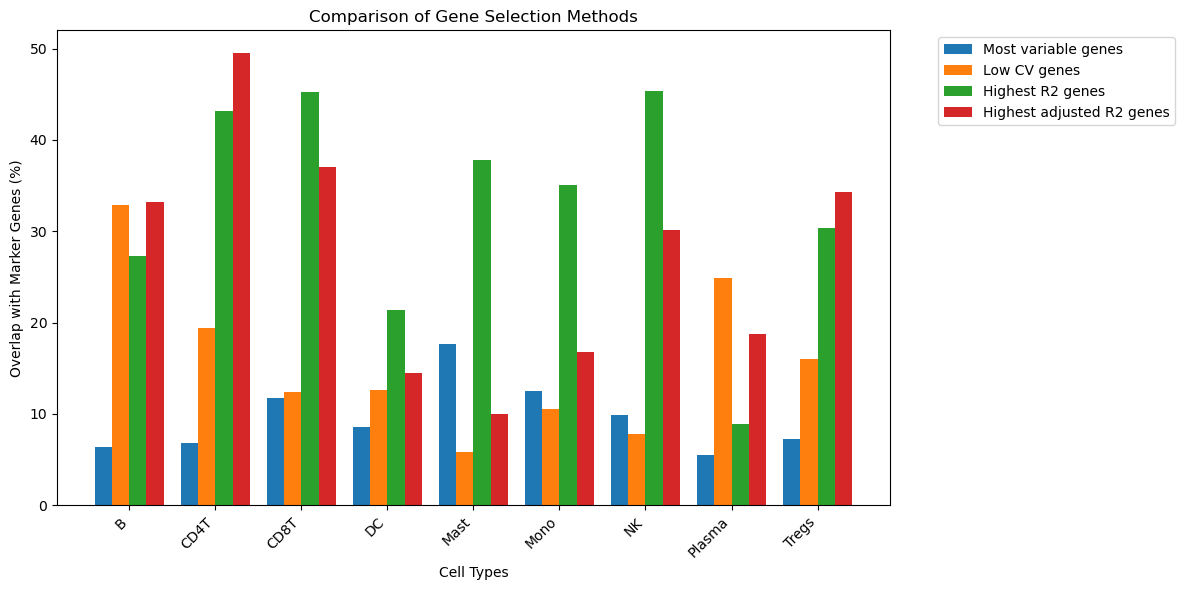

In [32]:
# Create bar plot comparing methods
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(12, 6))

# Get positions for bars
x = np.arange(len(overlap_df.index))
width = 0.2  # Width of bars

# Plot bars for each method
plt.bar(x - width*1.5, overlap_df['Most variable genes'], width, label='Most variable genes')
plt.bar(x - width/2, overlap_df['Low CV genes'], width, label='Low CV genes') 
plt.bar(x + width/2, overlap_df['Highest R2 genes'], width, label='Highest R2 genes')
plt.bar(x + width*1.5, overlap_df['Highest adjusted R2 genes'], width, label='Highest adjusted R2 genes')

# Customize plot
plt.xlabel('Cell Types')
plt.ylabel('Overlap with Marker Genes (%)')
plt.title('Comparison of Gene Selection Methods')
plt.xticks(x, overlap_df.index, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()


## Overlap analysis on 3rd Granularity

In [33]:
## Load CTI data for 3rd granularity
cti_data_3rd_gran = load_cti(n_variable_genes=None)
cti_data_3rd_gran = preprocess_scrna(cti_data_3rd_gran["dataset"], keep_genes=None, batch_key="donor_id")
cti_data_3rd_gran, _ = add_cell_types_grouped(cti_data_3rd_gran, "3rd_level_granularity")
single_cell_data_3rd_gran = cti_data_3rd_gran.to_df()

In [34]:
# --- Common genes across datasets ---
common_genes = list(set(bulk_facs_data.columns) & set(bulk_facs_tpm_data.columns) & set(single_cell_data.columns))
X = cti_data_3rd_gran[:, common_genes].X
group_codes, groups = pd.factorize(cti_data_3rd_gran.obs["cell_types_grouped_3rd_level_granularity"].values,sort=True) 
to_remove_mask = cti_data_3rd_gran.obs["cell_types_grouped_3rd_level_granularity"] == "To remove"
X_clean = X[~to_remove_mask]
X_clean.shape

(305912, 29643)

In [35]:
sc_data = {}
for code, group in enumerate(groups):
    if group != "To remove":
        sc_data[group] = X[group_codes == code]

### Fisher R2 ordered genes for 3rd granularity

In [45]:
fisher_r2_3rd_gran = calculate_fisher_r2(X_clean, sc_data)
fisher_r2_3rd_gran = pd.Series(fisher_r2_3rd_gran, index=common_genes)
fisher_r2_3rd_gran.sort_values(ascending=False, inplace=True)
highest_r2_genes_3rd_gran = list(fisher_r2_3rd_gran.index[:2000])

In [46]:
fisher_r2_3rd_gran.head(2000)

ENSG00000163751    0.933548
ENSG00000172236    0.892401
ENSG00000085265    0.861565
ENSG00000156738    0.856771
ENSG00000105369    0.851331
                     ...   
ENSG00000245954    0.083808
ENSG00000183386    0.083750
ENSG00000149357    0.083741
ENSG00000173540    0.083691
ENSG00000120875    0.083654
Length: 2000, dtype: float64

In [47]:
with open('project/highest_r2_genes_3rd_gran.pkl', 'wb') as f:
    pickle.dump(highest_r2_genes_3rd_gran, f)

### Adjusted R2 ordered genes for 3rd granularity

In [48]:
adjusted_fisher_r2_3rd_gran = calculate_adjusted_fisher_r2(X_clean, sc_data)
adjusted_fisher_r2_3rd_gran = pd.Series(adjusted_fisher_r2_3rd_gran, index=common_genes)
adjusted_fisher_r2_3rd_gran.sort_values(ascending=False, inplace=True)
highest_adjr2_genes_3rd_gran = list(adjusted_fisher_r2_3rd_gran.index[:2000])

100%|██████████| 16/16 [00:00<00:00, 8417.02it/s]


In [49]:
adjusted_fisher_r2_3rd_gran.head(2000)

ENSG00000156508    8.799113e+06
ENSG00000177954    8.223097e+06
ENSG00000133639    8.202259e+06
ENSG00000251562    7.693838e+06
ENSG00000149273    7.218813e+06
                       ...     
ENSG00000172922    1.192275e+04
ENSG00000087274    1.191473e+04
ENSG00000260314    1.188772e+04
ENSG00000133983    1.187871e+04
ENSG00000110917    1.187812e+04
Length: 2000, dtype: float64

In [50]:
with open('project/highest_adj_r2_genes_3rd_gran.pkl', 'wb') as f:
    pickle.dump(highest_adjr2_genes_3rd_gran, f)

### Compare to the signature matrix of 3rd granularity

In [55]:
sc_data.keys()

dict_keys(['DC', 'ImmatureB', 'Macro', 'Mast', 'MemB', 'Mem_CD4T', 'Mem_CD8T', 'Mono', 'NK', 'NaiveB', 'Naive_CD4T', 'Naive_CD8T', 'Plasma', 'Tregs', 'gdT', 'pDC'])

In [63]:
# Saving to use with rowsetta
marker_genes_3rd_gran = {}

for group in sc_data.keys():
    group_df = pd.read_csv(f'../project/Simon/signature_3rd_level_granularity/DE_{group}.txt', sep='\t', index_col=0)
    marker_genes_3rd_gran[group] = list(group_df.index)
    
with open('project/marker_genes_3rd_gran.pkl', 'wb') as f:
    pickle.dump(marker_genes_3rd_gran, f)

In [77]:
with open('project/marker_genes_3rd_gran_ensembl.pkl', 'rb') as f:
    marker_genes_3rd_gran_ensembl = pickle.load(f)

marker_genes_3rd_gran_ensembl.keys()

dict_keys(['DC', 'ImmatureB', 'Macro', 'Mast', 'MemB', 'Mem_CD4T', 'Mem_CD8T', 'Mono', 'NK', 'NaiveB', 'Naive_CD4T', 'Naive_CD8T', 'Plasma', 'Tregs', 'gdT', 'pDC'])

In [81]:
methods_3rd_gran = {
    'Most variable genes': most_variable_genes,
    'Low CV genes': low_CV_genes,
    'Highest R2 genes': highest_r2_genes_3rd_gran,
    'Highest adjusted R2 genes': highest_adjr2_genes_3rd_gran
}

overlap_results_3rd_gran = {}

for method_name, method_genes in methods_3rd_gran.items():
    overlap_results_3rd_gran[method_name] = {}
    
    for cell_type, marker_gene_list in marker_genes_3rd_gran_ensembl.items():
        overlap = len(set(marker_gene_list) & set(method_genes))
        overlap_percentage = (overlap / len(marker_gene_list)) * 100
        overlap_results_3rd_gran[method_name][cell_type] = overlap_percentage

In [82]:
overlap_df_3rd_gran = pd.DataFrame(overlap_results_3rd_gran)
print("\nOverlap percentages with marker genes by cell type:")
overlap_df_3rd_gran


Overlap percentages with marker genes by cell type:


,Most variable genes,Low CV genes,Highest R2 genes,Highest adjusted R2 genes
DC,5.703658,10.849349,13.205208,10.167390
ImmatureB,4.569892,1.075269,7.795699,3.225806
Macro,7.841311,14.434718,18.327435,15.272863
Mast,18.614719,3.463203,34.199134,5.194805
MemB,5.909091,9.090909,30.000000,18.181818
Mem_CD4T,5.185185,15.555556,40.740741,39.259259
Mem_CD8T,14.062500,9.375000,39.843750,28.125000
Mono,7.467532,8.603896,27.272727,11.688312
NK,9.649123,3.947368,40.350877,27.192982
NaiveB,2.970297,3.960396,39.603960,9.900990


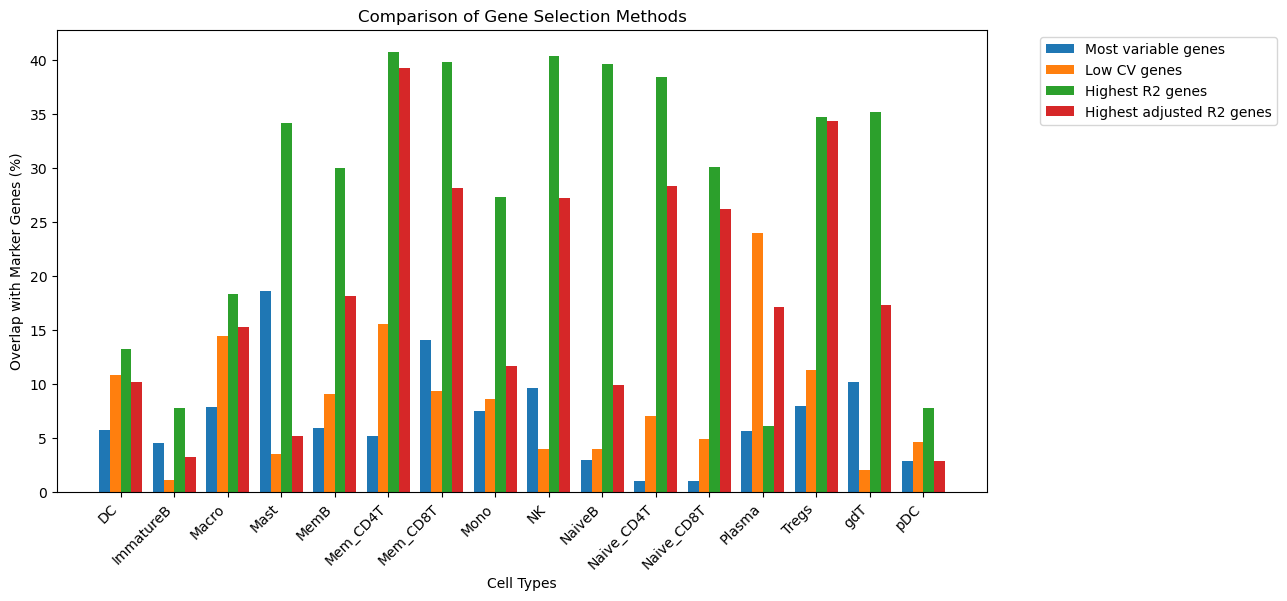

In [84]:
plt.figure(figsize=(12, 6))

# Get positions for bars
x = np.arange(len(overlap_df_3rd_gran.index))
width = 0.2  # Width of bars

# Plot bars for each method
plt.bar(x - width*1.5, overlap_df_3rd_gran['Most variable genes'], width, label='Most variable genes')
plt.bar(x - width/2, overlap_df_3rd_gran['Low CV genes'], width, label='Low CV genes') 
plt.bar(x + width/2, overlap_df_3rd_gran['Highest R2 genes'], width, label='Highest R2 genes')
plt.bar(x + width*1.5, overlap_df_3rd_gran['Highest adjusted R2 genes'], width, label='Highest adjusted R2 genes')

# Customize plot
plt.xlabel('Cell Types')
plt.ylabel('Overlap with Marker Genes (%)')
plt.title('Comparison of Gene Selection Methods')
plt.xticks(x, overlap_df_3rd_gran.index, rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## EXTRA: How much do the metrics dependent on the granularity vary?

In [88]:
methods_2nd_gran = methods

# Calculate overlap between 2nd and 3rd granularity for highest R2 genes
r2_overlap = len(set(methods_2nd_gran['Highest R2 genes']) & set(methods_3rd_gran['Highest R2 genes']))
r2_overlap_percentage = (r2_overlap / 2000) * 100

# Calculate overlap between 2nd and 3rd granularity for highest adjusted R2 genes  
adj_r2_overlap = len(set(methods_2nd_gran['Highest adjusted R2 genes']) & set(methods_3rd_gran['Highest adjusted R2 genes']))
adj_r2_overlap_percentage = (adj_r2_overlap / 2000) * 100

print(f"Overlap between 2nd and 3rd granularity highest R2 genes: {r2_overlap_percentage:.2f}%")
print(f"Overlap between 2nd and 3rd granularity highest adjusted R2 genes: {adj_r2_overlap_percentage:.2f}%")


Overlap between 2nd and 3rd granularity highest R2 genes: 82.50%
Overlap between 2nd and 3rd granularity highest adjusted R2 genes: 92.70%
